# Exercise 1: K-Means Algorithm

You are given a dataset that contains statistics about years of work experience and its corresponding salary. The dataset can be found together with this exercise or you can download from https://www.kaggle.com/datasets/rohankayan/years-of-experience-and-salary-dataset
<br>
<br>

**The dataset comprises 2 columns as follows:**
- YearsExperience: Number of working years.
- Salary: Annual salary.

<br>

**Now, you are required to import sklearn library and find out the optimum number of clusters by following the task below.** 


### Task 1
- Load the "Salary_Data.csv" dataset and perform basic data preprocessing steps.

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import warnings
# Ignore FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Ignore UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [8]:
df = pd.read_csv("Salary_Data.csv")
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


## Task 2
- Perform some basic visualization of the dataset to gain some insights from the data.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [10]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


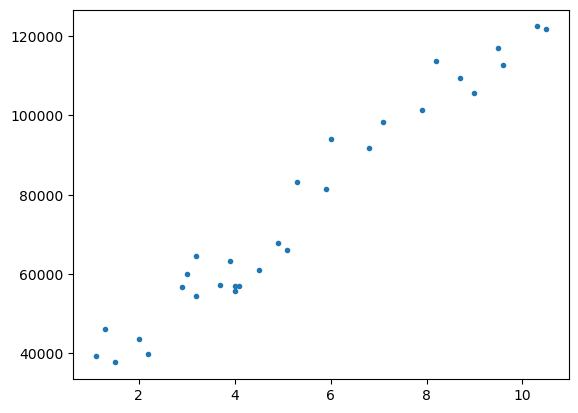

In [17]:
plt.scatter(df['YearsExperience'], df['Salary'], marker= '.')

## Task 3
- Scale the features using the standard scaler from sklearn.

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
# take only numerical inputs, in this case the whole dataset can be used
iloced_df = df.iloc[:, :]

#create stdscaler object
stdscaler = StandardScaler()

#each row is a data point/observation, each column is a feature
#fit the stdscaler to the training data to compute mean and std dev for each feature
stdscaler.fit(iloced_df)

#apply scaling computed back to each feature in the dataset
transformed_df = stdscaler.transform(iloced_df)

#convert back to pandas df with original df columns
scaled_df = pd.DataFrame(transformed_df, columns=df.columns)
scaled_df


,YearsExperience,Salary
0,-1.510053,-1.360113
1,-1.438373,-1.105527
2,-1.366693,-1.419919
3,-1.187494,-1.204957
4,-1.115814,-1.339781
5,-0.864935,-0.718307
6,-0.829096,-0.588158
7,-0.757416,-0.799817
8,-0.757416,-0.428810
9,-0.578216,-0.698013


In [20]:
#do prof way
from sklearn.preprocessing import scale as scale

scaled_df = pd.DataFrame(scale(df.iloc[:,:]),columns=df.columns)
scaled_df = pd.DataFrame(scaled_df)
scaled_df

,YearsExperience,Salary
0,-1.510053,-1.360113
1,-1.438373,-1.105527
2,-1.366693,-1.419919
3,-1.187494,-1.204957
4,-1.115814,-1.339781
5,-0.864935,-0.718307
6,-0.829096,-0.588158
7,-0.757416,-0.799817
8,-0.757416,-0.428810
9,-0.578216,-0.698013


## Task 4
- Determine the optimum number of clusters for this dataset using the elbow method.
- Then plot the elbow.

In [21]:
k_range = range(1,11)
k_wcss = []

from sklearn.cluster import KMeans
for kclusternumber in k_range:
    clusters = KMeans(kclusternumber)
    clusters.fit(scaled_df)
    k_wcss.append(clusters.inertia_)

from collections import OrderedDict
clusters_df = pd.DataFrame(OrderedDict(
    {"k_clusters": k_range,
     "k_wcss": k_wcss}
))
clusters_df

,k_clusters,k_wcss
0,1,60.000000
1,2,12.746904
2,3,7.589320
3,4,3.072933
4,5,2.477636
5,6,1.556376
6,7,1.299490
7,8,0.906798
8,9,0.884733
9,10,0.761350


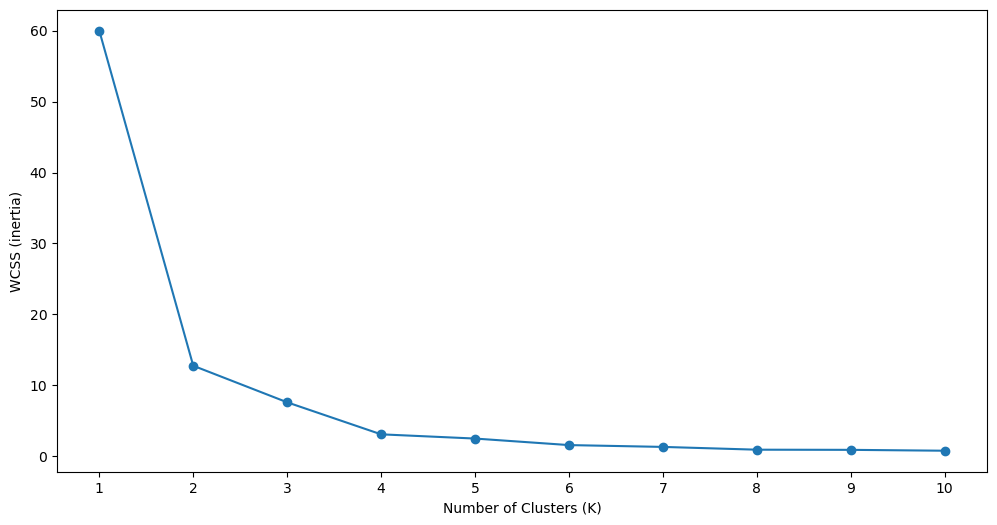

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (inertia)')
plt.xticks(np.arange(min(clusters_df.k_clusters),
                     max(clusters_df.k_clusters)+1,
                     1.0))
plt.plot(clusters_df.k_clusters,
         clusters_df.k_wcss,
         marker = "o")

## Task 5
- Explain in your own words what is elbow method. And what is optimum number of clusters based on the visualization plot in Task 4.

The elbow method is graphically plotting the WCSS between each data point and the k-means centroid its assigned to, as the number of clusters (K) increases. We aim to find the corner, the "elbow" where WCSS stops decreasing so much, roughly flattens, as the clusters increase. I see that happening when K = 4, so the optimum number of clusters is 4